In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

'''Verifica Integrità Temporale'''

# Configurazione grafici
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (15, 6)

# 1. Caricamento
df = pd.read_csv('../Data/merge_ds.csv') # Adatta il path
df['dt_iso'] = pd.to_datetime(df['dt_iso'], utc=True)
df = df.set_index('dt_iso').sort_index()

# 2. Verifica continuità temporale
# Generiamo un range ideale orario
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')
missing_timestamps = full_range.difference(df.index)

print(f"Totale righe: {len(df)}")
print(f"Timestamp mancanti: {len(missing_timestamps)}")

if len(missing_timestamps) > 0:
    print("ATTENZIONE: Ci sono buchi temporali! Devi fare reindex/imputazione in preprocessing.py")
    print(missing_timestamps[:5]) # Mostra i primi 5
else:
    print("Ottimo: La serie temporale è continua (nessun buco).")

Totale righe: 17544
Timestamp mancanti: 0
Ottimo: La serie temporale è continua (nessun buco).


rain_1h    13812
dtype: int64


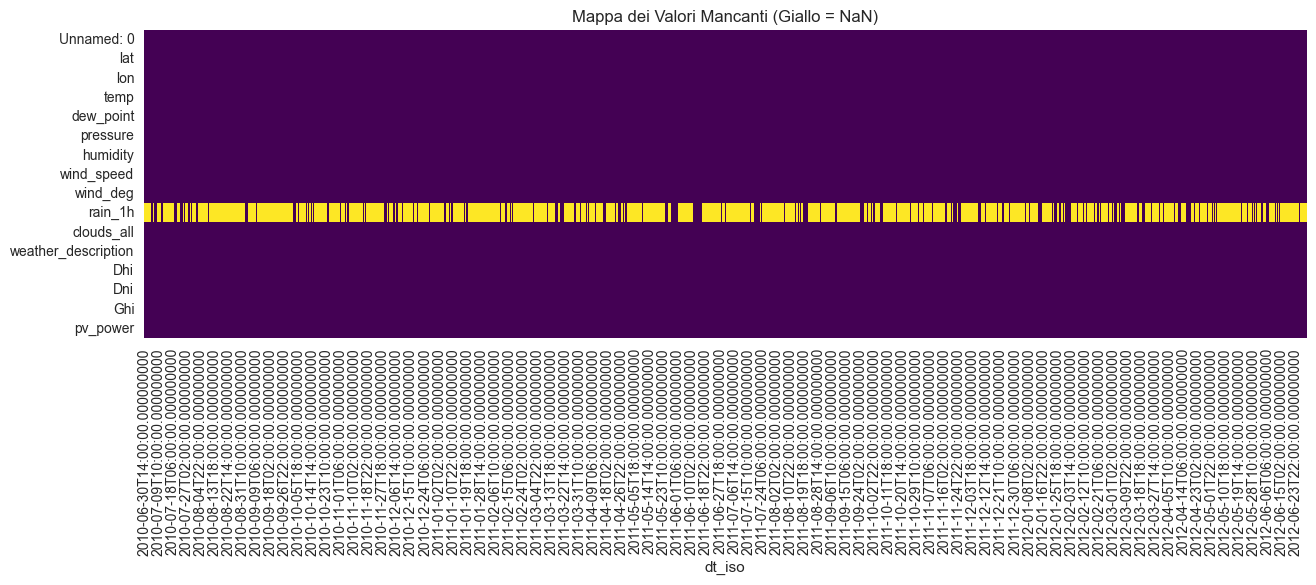

Statistiche pioggia (con fillna 0):
count    17544.000000
mean         0.124873
std          0.397985
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          6.730000
Name: rain_1h_filled, dtype: float64


In [ ]:
'''Analisi dei Valori Mancanti'''

# Controlliamo i null
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

# Visualizzazione rapida di dove sono i buchi (es. sensore rotto per 3 giorni?)
plt.figure(figsize=(15, 4))
sns.heatmap(df.isnull().T, cbar=False, cmap='viridis')
plt.title("Mappa dei Valori Mancanti (Giallo = NaN)")
plt.show()

# CHECK SPECIFICO: Rain e Wind
# Se 'rain_1h' è NaN, spesso significa 0 pioggia. Verifichiamo la teoria.
df['rain_1h_filled'] = df['rain_1h'].fillna(0)
print("Statistiche pioggia (con fillna 0):")
print(df['rain_1h_filled'].describe())

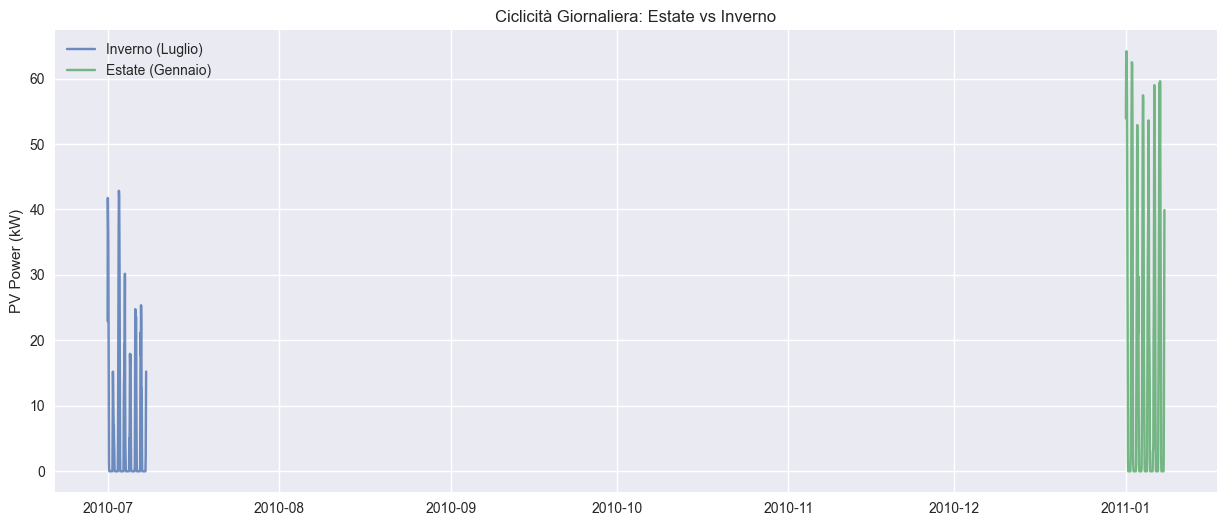

Media PV Power quando Irradianza (GHI) è 0: 0.0530


In [ ]:
"Analisi del Target (PV Power) e Stagionalità Giornaliera"

# Prendiamo un mese estivo e uno invernale (dataset nell'emisfero australe? Australia? Occhio ai mesi!)
# Luglio (Inverno lì) vs Gennaio (Estate lì)
subset_winter = df['2010-07-01':'2010-07-07'] # Prima settimana
subset_summer = df['2011-01-01':'2011-01-07']

plt.figure(figsize=(15, 6))
plt.plot(subset_winter.index, subset_winter['pv_power'], label='Inverno (Luglio)', alpha=0.8)
plt.plot(subset_summer.index, subset_summer['pv_power'], label='Estate (Gennaio)', alpha=0.8)
plt.title("Ciclicità Giornaliera: Estate vs Inverno")
plt.ylabel("PV Power (kW)")
plt.legend()
plt.show()

# Zoom sulla notte
night_values = df[df['Ghi'] == 0]['pv_power']
print(f"Media PV Power quando Irradianza (GHI) è 0: {night_values.mean():.4f}")

Insight per il Modello:
Se d'inverno il picco è 2000 e d'estate è 4000, la serie non è stazionaria. Dovrai normalizzare i dati
 o usare feature che indicano il mese (seno/coseno dell'anno).

Se di notte il PV non è esattamente 0 (rumore del sensore), in preprocessing.py devi forzarlo a 0:
 df.loc[df['Ghi'] == 0, 'pv_power'] = 0. Questo aiuta la rete a convergere prima.

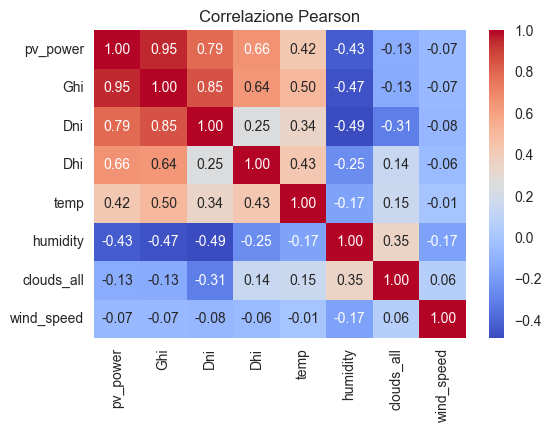

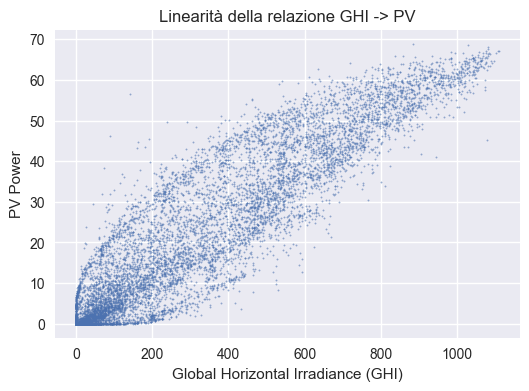

In [13]:
'''Feature Importance (Correlazioni)'''

# Matrice di correlazione
cols_to_check = ['pv_power', 'Ghi', 'Dni', 'Dhi', 'temp', 'humidity', 'clouds_all', 'wind_speed']
corr = df[cols_to_check].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlazione Pearson")
plt.show()

# Scatter Plot: GHI vs PV Power (La relazione fisica)
plt.figure(figsize=(6, 4))
plt.scatter(df['Ghi'], df['pv_power'], alpha=0.5, s=1)
plt.xlabel("Global Horizontal Irradiance (GHI)")
plt.ylabel("PV Power")
plt.title("Linearità della relazione GHI -> PV")
plt.show()

Quali input servono davvero? Usiamo una heatmap e uno scatter plot fisico
Insight per Feature Engineering:

Ghi avrà correlazione altissima (>0.9). È il driver principale.

Guarda lo Scatter Plot: se vedi una linea retta pulita, bene. Se vedi una "nuvola" dispersa o
punti con GHI alto ma PV zero, sono anomalie/outliers (es. pannello spento per manutenzione).

Azione: Se trovi punti Ghi > 500 ma pv_power == 0, filtrali via nel training set, altrimenti la rete si
confonde!

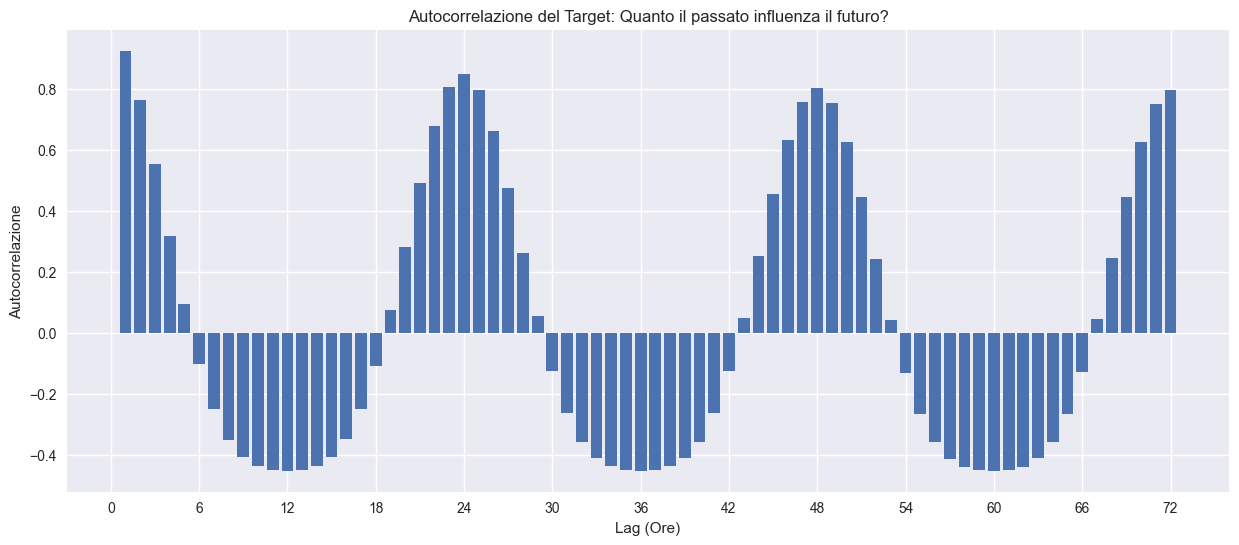

'Questo decide la dimensione della tua sliding window (seq_len)\nInsight per Data Loader: Vedrai picchi a 24h, 48h, 72h.\n\nSe l\'autocorrelazione a 24h è alta (es. > 0.8), significa che "domani sarà simile a oggi".\n\nDecisione: La tua input_window deve essere almeno di 24 ore, meglio 48 o 72, per catturare questo ciclo. \nSe metti una finestra di 6 ore, la rete non saprà in che punto del giorno si trova.'

In [ ]:
'''Autocorrelazione (Quanto guardare indietro)'''

from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(15, 6))
# Limitiamo il plot ai primi 72 lag (3 giorni) per leggibilità
# Pandas autocorrelation_plot è lento su tutto il dataset, usiamo una slice
lags = 72
corr_vals = [df['pv_power'].autocorr(lag=i) for i in range(1, lags+1)]

plt.bar(range(1, lags+1), corr_vals)
plt.xlabel("Lag (Ore)")
plt.ylabel("Autocorrelazione")
plt.title("Autocorrelazione del Target")
plt.xticks(np.arange(0, lags+1, 6)) # Tick ogni 6 ore
plt.show()

Questo decide la dimensione della tua sliding window (seq_len)
Insight per Data Loader: Vedrai picchi a 24h, 48h, 72h.

Se l'autocorrelazione a 24h è alta (es. > 0.8), significa che "domani sarà simile a oggi".

Decisione: La tua input_window deve essere almeno di 24 ore, meglio 48 o 72, per catturare questo ciclo. 
Se metti una finestra di 6 ore, la rete non saprà in che punto del giorno si trova.